In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from dolfin import Function, plot
def gr1(V, sol, levels=20, fs=(6.5,4)):
    u = Function(V); u.vector()[:] = sol
    plt.figure(figsize=fs)
    p = plot(u); plot(u, mode='contour', levels=levels, colors='k', linewidths=0.3)
    cax = make_axes_locatable(plt.gca()).append_axes('right', size="3%", pad=0.2)
    plt.colorbar(p, cax=cax); plt.tight_layout(); plt.show()

In [2]:
def gr2(x, y):
    plt.figure(figsize=(6,3))
    plt.plot(x, y, lw=2)
    plt.grid(alpha=0.3); plt.xlabel('x'); plt.ylabel('y')
    plt.tight_layout(); plt.show()

In [3]:
from dolfin import * ; import numpy as np
set_log_level(LogLevel.WARNING)
N = 100; 
T = 0.1; M = 100; tau = T/M

gamma = 100
def p(t):
    return -1000*t/(1 + np.exp(gamma*(t-0.5*T)))
def boundary(x):
    return x[0] < DOLFIN_EPS or x[0] > 1.0 - DOLFIN_EPS or \
        x[1] < DOLFIN_EPS or x[1] > 1.0 - DOLFIN_EPS
        
mesh= UnitSquareMesh(N, N)
V= FunctionSpace(mesh, 'Lagrange', 1)

bc=DirichletBC(V, Constant(0.0), boundary); u0= interpolate(Expression("sin(pi*x[0])*sin(pi*x[1])", degree=1), V)
f = Expression("beta*x[0]*x[1]", beta=1, degree=1)
p0 = Constant(p(0.0))
u= TrialFunction(V); v = TestFunction(V)
a= (1/tau)*inner(u, v)*dx + inner(grad(u), grad(v))*dx #- p0*inner(u,v)*dx
L= (1/tau)*inner(u0,v)*dx + inner(f, v) * dx + p0*inner(u0, v)*dx

u = Function(V)
solutions = []

t = 0
while t < T:
    t += tau
    solve(a == L, u, bc)
    solutions.append(u.vector().get_local().copy())
    p0.assign(p(t))
    u0.assign(u)

solutions = np.array(solutions)

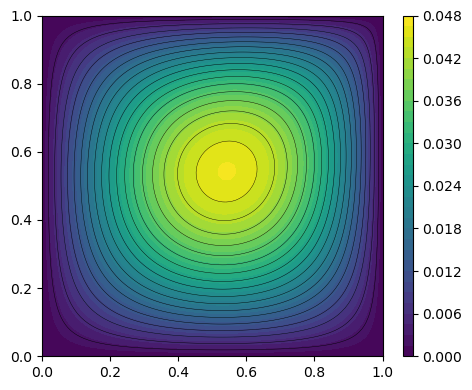

In [12]:
gr1(V, solutions[-1])

Функция $p(t)$

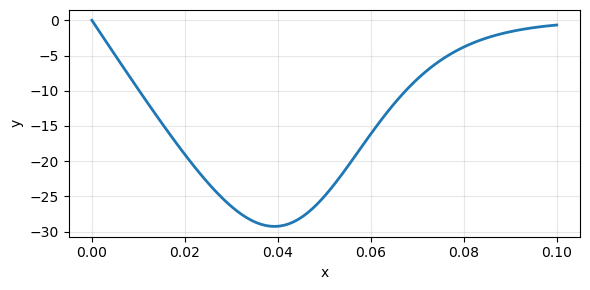

In [5]:
t = np.linspace(0, T, M)
gr2(t, p(t))

Функция переопределения

In [6]:
from dolfin import * ; import numpy as np
set_log_level(LogLevel.WARNING)
N = 100; 
T = 0.1; M = 100; tau = T/M

gamma = 100

def boundary(x):
    return x[0] < DOLFIN_EPS or x[0] > 1.0 - DOLFIN_EPS or \
        x[1] < DOLFIN_EPS or x[1] > 1.0 - DOLFIN_EPS
        
mesh= UnitSquareMesh(N, N)
V= FunctionSpace(mesh, 'Lagrange', 1)

eta_fun = interpolate(Expression("x[0]*x[1]", degree=1), V)  # пример η
phi_t = []
for sol  in solutions:
    u = Function(V); u.vector()[:] = sol
    phi_t.append(assemble(eta_fun * u * dx))

bc=DirichletBC(V, Constant(0.0), boundary);
f = Expression("beta*x[0]*x[1]", beta=1, degree=1)

z = TrialFunction(V);
v1 = TestFunction(V);

y0 = interpolate(Expression("sin(pi*x[0])*sin(pi*x[1])", degree=1), V)
a_z= inner(z, v1)*dx + tau*inner(grad(z), grad(v1))*dx
L_z= inner(y0, v1)*dx + tau*inner(f, v1) * dx

w = TrialFunction(V);
v2 = TestFunction(V);
a_w =inner(w, v2)*dx + tau*inner(grad(w), grad(v2))*dx
L_w =tau*inner(y0, v2) * dx

z_ = Function(V)
w_ = Function(V)
y = Function(V)
sol_z = []
sol_w = []
sol_y = []
sol_p = []
t = 0
j = 0
while t < T:
    t += tau
    solve(a_z == L_z, z_, bc)
    solve(a_w == L_w, w_, bc)
    eta_z = assemble(eta_fun * z_ * dx)
    eta_w = assemble(eta_fun * w_ * dx)
    p0 = (phi_t[j] - eta_z) / eta_w
    
    y.vector()[:] = z_.vector().get_local() + p0 * w_.vector().get_local()
    sol_z.append(z_.vector().get_local().copy())
    sol_w.append(w_.vector().get_local().copy())
    sol_y.append(y.vector().get_local().copy())
    sol_p.append(p0)
    y0.assign(y)
    
    j+=1

sol_z = np.array(sol_z)
sol_w = np.array(sol_w)
sol_y = np.array(sol_y)
sol_p = np.array(sol_p)

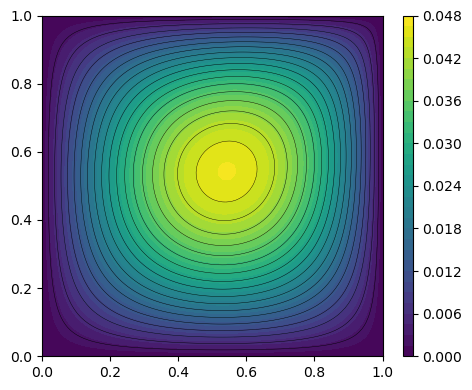

In [7]:
gr1(V, sol_y[-1])

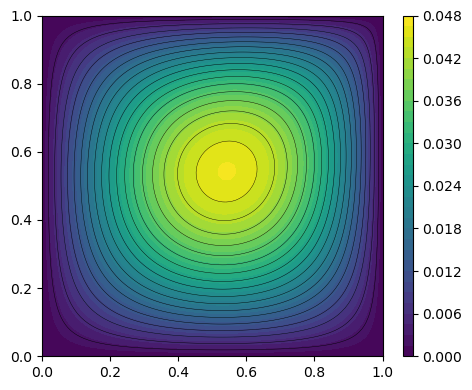

In [8]:
gr1(V, solutions[-1])

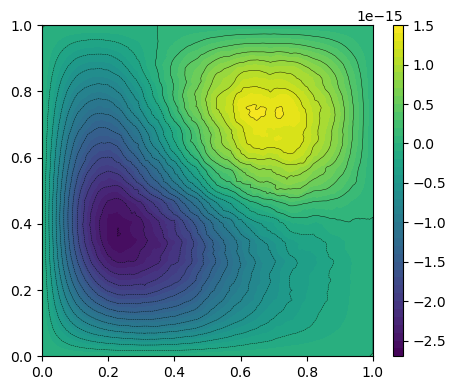

In [10]:
gr1(V, solutions[-1]-sol_y[-1])

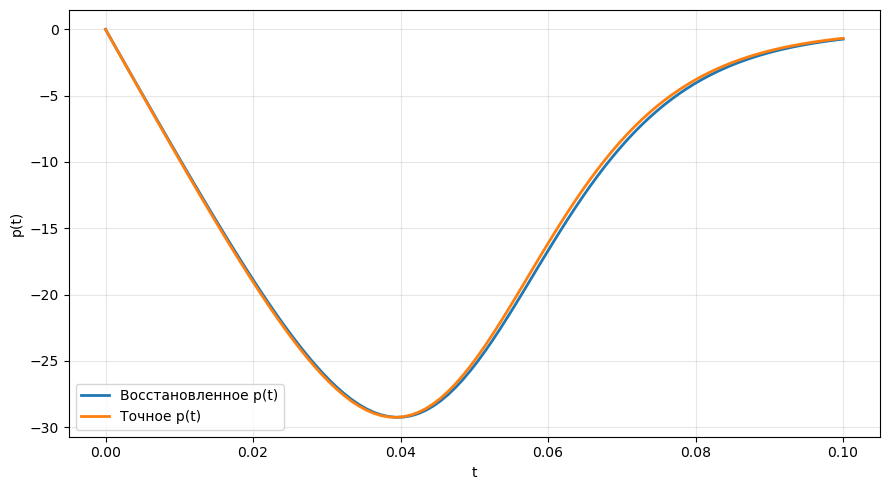

In [9]:
t = np.linspace(0, T, M)
plt.figure(figsize=(9,5))
plt.plot(t, sol_p, lw=2, label='Восстановленное p(t)')
plt.plot(t, p(t), lw=2, label='Точное p(t)')
plt.grid(alpha=0.3); plt.xlabel('t'); plt.ylabel('p(t)'); plt.legend()
plt.tight_layout(); plt.show()

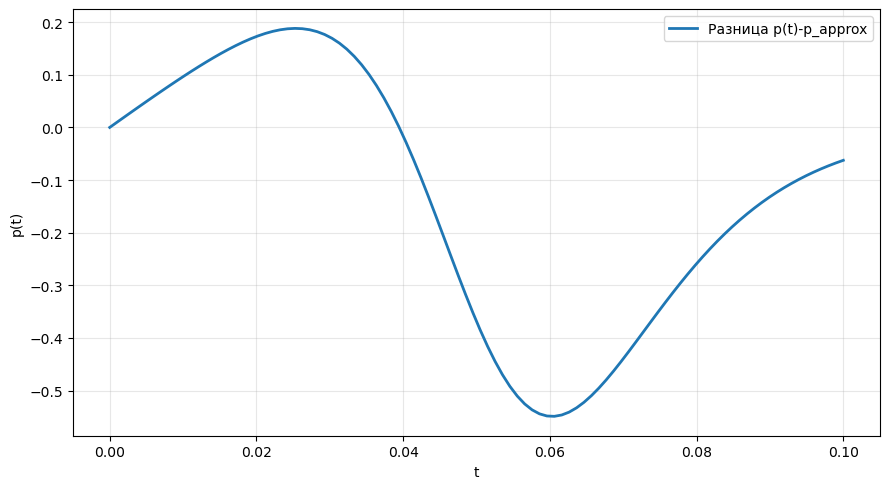

In [11]:
t = np.linspace(0, T, M)
plt.figure(figsize=(9,5))
plt.plot(t, sol_p-p(t), lw=2, label='Разница p(t)-p_approx')
plt.grid(alpha=0.3); plt.xlabel('t'); plt.ylabel('p(t)'); plt.legend()
plt.tight_layout(); plt.show()